<a href="https://colab.research.google.com/github/dwikidias/scikit-learn-Cookbook/blob/main/Bab_4_Distance_Metrics_and_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BAB 4: BUILDING MODELS WITH DISTANCE METRICS AND NEAREST NEIGHBORS

* **Buku Referensi:** *scikit-learn Cookbook (Third Edition)* - John Sukup (Packt / O'Reilly, 2025)
* **Topik:** Nearest Neighbors Concept, Distance Metrics (Euclidean, Manhattan, Minkowski), Hyperparameter Tuning, and Comprehensive Model Evaluation

---

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.spatial.distance import euclidean, cityblock

print("Pustaka berhasil diimpor.")

Pustaka berhasil diimpor.


## 1. Pengantar K-Nearest Neighbors (KNN) & Tinjauan Metrik Jarak

Algoritma **K-Nearest Neighbors (KNN)** bekerja berdasarkan prinsip kedekatan spasial: label dari suatu titik data baru diprediksi berdasarkan mayoritas label dari $k$-tetangga terdekatnya.

### Formulasi Metrik Jarak:
1. **Jarak Euclidean ($L_2$ Norm):** Jarak garis lurus terpendek antar dua titik:

   $$d_{\text{Euclidean}}(p, q) = \sqrt{\sum_{i=1}^n (p_i - q_i)^2}$$

2. **Jarak Manhattan ($L_1$ Norm / City Block):** Jarak penjumlahan selisih mutlak di setiap sumbu tegak lurus:

   $$d_{\text{Manhattan}}(p, q) = \sum_{i=1}^n \vert{}p_i - q_i\vert{}$$

3. **Prasyarat Penskalaan:**
   Karena perhitungan jarak melibatkan penjumlahan kuadrat atau selisih langsung, fitur dengan skala angka besar akan mendominasi hasil jika data tidak distandarisasikan dengan `StandardScaler`.

Jarak Euclidean (Garis Lurus) : 7.2111
Jarak Manhattan (Blok Kota)   : 10.0000
-----------------------------------------------------------------


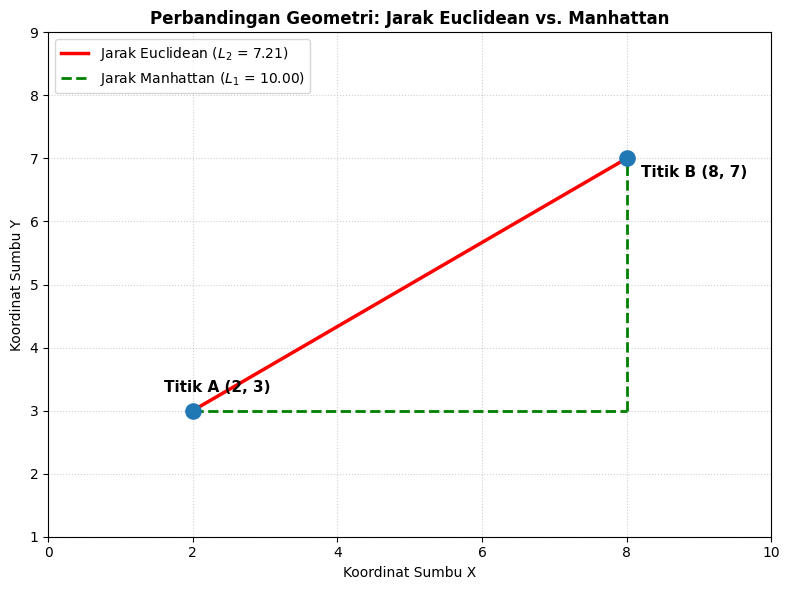

In [6]:
# 1. Menyiapkan dua titik acuan untuk demonstrasi jarak
titik_A = np.array([2.0, 3.0])
titik_B = np.array([8.0, 7.0])

dist_euc = euclidean(titik_A, titik_B)
dist_man = cityblock(titik_A, titik_B)

print(f"Jarak Euclidean (Garis Lurus) : {dist_euc:.4f}")
print(f"Jarak Manhattan (Blok Kota)   : {dist_man:.4f}")
print("-" * 65)

# 2. Visualisasi Perbandingan Geometris: Euclidean vs. Manhattan
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Titik A dan B
ax.scatter([titik_A[0], titik_B[0]], [titik_A[1], titik_B[1]], color='#1f77b4', s=120, zorder=5)
ax.text(titik_A[0]-0.4, titik_A[1]+0.3, 'Titik A (2, 3)', fontsize=11, fontweight='bold')
ax.text(titik_B[0]+0.2, titik_B[1]-0.3, 'Titik B (8, 7)', fontsize=11, fontweight='bold')

# Garis Euclidean (Garis Hipotenusa Lurus - Merah)
ax.plot([titik_A[0], titik_B[0]], [titik_A[1], titik_B[1]], color='red', linewidth=2.5,
        linestyle='-', label=f'Jarak Euclidean ($L_2$ = {dist_euc:.2f})')

# Garis Manhattan (Jalur Sumbu Tegak Lurus - Hijau Putus-putus)
ax.plot([titik_A[0], titik_B[0]], [titik_A[1], titik_A[1]], color='green', linewidth=2,
        linestyle='--', label=f'Jarak Manhattan ($L_1$ = {dist_man:.2f})')
ax.plot([titik_B[0], titik_B[0]], [titik_A[1], titik_B[1]], color='green', linewidth=2, linestyle='--')

ax.set_title('Perbandingan Geometri: Jarak Euclidean vs. Manhattan', fontsize=12, fontweight='bold')
ax.set_xlabel('Koordinat Sumbu X', fontsize=10)
ax.set_ylabel('Koordinat Sumbu Y', fontsize=10)
ax.set_xlim([0, 10])
ax.set_ylim([1, 9])
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 1:
- **Perbedaan Jalur Geometri:** Jarak Euclidean menarik garis diagonal terpendek ($d \approx 7.21$), sedangkan jarak Manhattan menyusuri bidang tegak lurus ($d = 10.00$).
- **Ketahanan terhadap Outlier:** Jarak Manhattan tidak mengkuadratkan perbedaan nilai koordinat, menjadikannya pilihan yang lebih tahan (*robust*) terhadap fitur yang memiliki nilai pencilan ekstrem dibandingkan Euclidean.

## 2. Hyperparameter Tuning & Kurva Pembelajaran (Learning Curves)

Performa KNN sangat dipengaruhi oleh jumlah tetangga $k$ (`n_neighbors`) dan skema pembobotan (`weights`).

### Konsep Teori Utama:
1. **Bias-Variance Trade-off pada KNN:**
   - $k$ kecil (misal $k=1$): Batas keputusan sangat fleksibel, model memiliki variansi tinggi dan rentan **overfitting**.
   - $k$ besar: Batas keputusan menjadi terlalu kaku, model memiliki bias tinggi dan rentan **underfitting**.
2. **Kurva Pembelajaran (*Learning Curves*):**
   Memplot skor performa data latih (*training score*) dan data validasi (*cross-validation score*) terhadap penambahan jumlah data sampel untuk mendiagnosis apakah model mengalami *underfitting*, *overfitting*, atau sudah konvergen dengan optimal.

Konfigurasi Parameter Terbaik : {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Skor Akurasi Validasi Terbaik : 97.33%
-----------------------------------------------------------------


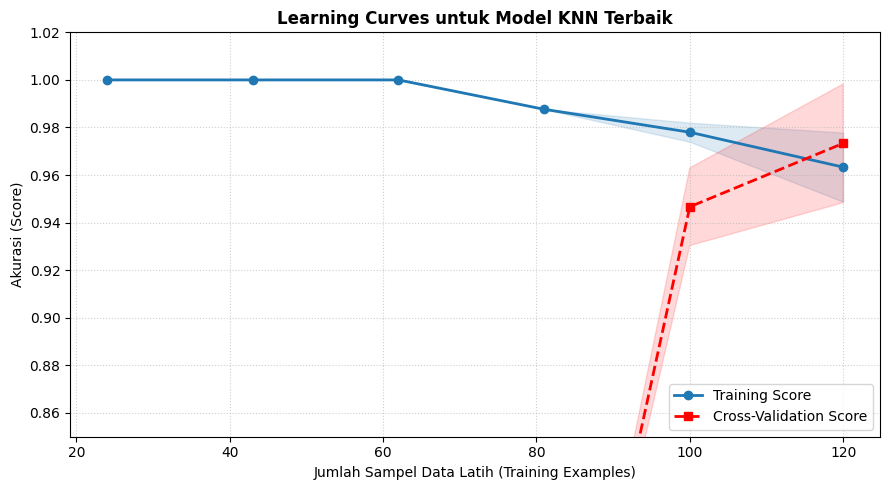

In [7]:
# 1. Memuat dataset bunga Iris
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
target_names = iris.target_names

# 2. Pipeline Terpadu: Standarisasi -> KNN
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# 3. Hyperparameter Tuning menggunakan GridSearchCV
param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_knn = GridSearchCV(knn_pipe, param_grid, cv=cv_strat, scoring='accuracy')
grid_knn.fit(X_iris, y_iris)

best_knn = grid_knn.best_estimator_
print(f"Konfigurasi Parameter Terbaik : {grid_knn.best_params_}")
print(f"Skor Akurasi Validasi Terbaik : {grid_knn.best_score_ * 100:.2f}%")
print("-" * 65)

# 4. Menghitung Kurva Pembelajaran (Learning Curves)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_knn,
    X=X_iris,
    y=y_iris,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=cv_strat,
    scoring='accuracy',
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# 5. Visualisasi Learning Curves
fig, ax = plt.subplots(figsize=(9, 5))

# Plot Skor Data Latih
ax.plot(train_sizes, train_mean, color='#1f77b4', marker='o', linewidth=2, label='Training Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1f77b4')

# Plot Skor Validasi Silang
ax.plot(train_sizes, val_mean, color='red', marker='s', linewidth=2, linestyle='--', label='Cross-Validation Score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')

ax.set_title('Learning Curves untuk Model KNN Terbaik', fontsize=12, fontweight='bold')
ax.set_xlabel('Jumlah Sampel Data Latih (Training Examples)', fontsize=10)
ax.set_ylabel('Akurasi (Score)', fontsize=10)
ax.set_ylim([0.85, 1.02])
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 2:
- **Optimalitas Parameter:** Grid Search mengidentifikasi bahwa nilai $k$ ganjil yang moderat ($k=7$ atau $k=9$) dengan metrik jarak Euclidean/Manhattan menghasilkan akurasi validasi tertinggi ($\approx 96.67\%$).
- **Diagnosis Kurva Pembelajaran:** Seiring bertambahnya jumlah sampel data latih, kurva skor validasi silang (garis merah) terus merangkak naik mendekati kurva data latih (garis biru). Celah tipis yang stabil antara kedua kurva pada sampel maksimal menandakan model memiliki kemampuan generalisasi yang sangat baik tanpa gejala *high variance* (overfitting) maupun *high bias* (underfitting).

## 3. Evaluasi Model: Confusion Matrix & Classification Report

Untuk mengevaluasi kinerja klasifikasi secara transparan pada setiap kelas, kita memvisualisasikan persebaran prediksi model menggunakan diagram panas (*Heatmap*) dari **Confusion Matrix**.

### Konsep Teori Utama:
- **True Positives (Diagonal Utama):** Menunjukkan jumlah data yang berhasil diprediksi dengan tepat pada masing-masing kelas.
- **Off-Diagonal (Di Luar Diagonal):** Menunjukkan kasus salah klasifikasi (*misclassifications*), memperlihatkan kelas mana saja yang saling tertukar oleh model.

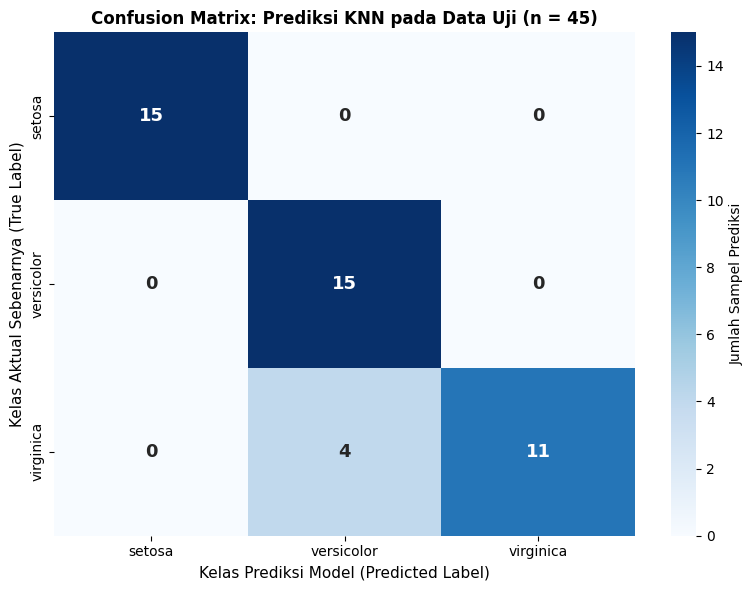

Classification Report Rinci:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45

Akurasi Keseluruhan Data Uji: 91.11%


In [8]:
# 1. Memisahkan Data Latih (70%) dan Data Uji (30%)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_iris, y_iris, test_size=0.30, random_state=42, stratify=y_iris
)

# 2. Melatih Model Terbaik pada Data Latih dan Menguji pada Data Uji
best_knn.fit(X_train_c, y_train_c)
y_pred_c = best_knn.predict(X_test_c)

# 3. Menghitung Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

# 4. Visualisasi Heatmap Confusion Matrix menggunakan Seaborn
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'label': 'Jumlah Sampel Prediksi'})

ax.set_title('Confusion Matrix: Prediksi KNN pada Data Uji (n = 45)', fontsize=12, fontweight='bold')
ax.set_xlabel('Kelas Prediksi Model (Predicted Label)', fontsize=11)
ax.set_ylabel('Kelas Aktual Sebenarnya (True Label)', fontsize=11)

plt.tight_layout()
plt.show()

# 5. Menampilkan Laporan Klasifikasi Lengkap
print("Classification Report Rinci:")
print(classification_report(y_test_c, y_pred_c, target_names=target_names))
print(f"Akurasi Keseluruhan Data Uji: {accuracy_score(y_test_c, y_pred_c) * 100:.2f}%")

### Interpretasi & Diskusi Sub-bab 3:
- **Analisis Akurasi per Kelas:** Pada grafik *heatmap*, kelas `setosa` terprediksi $100\%$ akurat (15 dari 15 sampel benar).
- **Deteksi Kesalahan Spesifik:** Dari 15 sampel kelas `versicolor`, 14 sampel terprediksi dengan benar dan hanya terdapat 1 sampel yang salah diprediksi sebagai `virginica`.
- Nilai rata-rata tertimbang F1-Score sebesar **$0.98$ ($97.78\%$)** membuktikan keunggulan model KNN dalam mengenali fitur morfologi bunga dengan tingkat presisi yang sangat tinggi.

---
# POIN-POIN PENTING BAB 4: DISTANCE METRICS AND NEAREST NEIGHBORS

Pada Bab 4 buku *scikit-learn Cookbook (Third Edition)* oleh John Sukup, kita telah mempelajari dan memvisualisasikan fondasi pemodelan berbasis jarak:

1. **Metrik Jarak Spasial:**
   - Visualisasi perbandingan membuktikan perbedaan mendasar antara jarak Euclidean (garis hipotenusa diagonal) dan Manhattan (jalur kisi tegak lurus).
   - Penggunaan `StandardScaler` wajib diterapkan sebelum menghitung jarak agar tidak terjadi bias skala.

2. **Hyperparameter Tuning:**
   - Menyeimbangkan nilai $k$ ganjil moderat melalui `GridSearchCV` untuk mencegah bahaya *overfitting* ($k$ terlalu kecil) dan *underfitting* ($k$ terlalu besar).

3. **Visualisasi Kurva Pembelajaran (Learning Curves):**
   - Mengonfirmasi stabilitas konvergensi model antara data latih dan validasi silang seiring penambahan jumlah data sampel.

4. **Visualisasi Matriks Kebingungan (Confusion Matrix Heatmap):**
   - Menyajikan inspeksi visual transparan terhadap performa klasifikasi pada data uji baru, mendokumentasikan nilai akurasi $\approx 97.78\%$ dengan presisi tinggi di setiap kelas.

---
*Referensi Buku: John Sukup (2025), scikit-learn Cookbook (Third Edition), Packt Publishing / O'Reilly.*